<a href="https://colab.research.google.com/github/LaviniBastos/Burnout-system/blob/main/exploratoria_geral_DadosCAT_INSS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise Exploratória da Base - Comunicação de Acidente de Trabalho (CAT/INSS).

### Projeto: Análise e Modelagem Preditiva de Afastamentos por Burnout / Transtornos Mentais

- Etapa: Análise exploratória em busca de insights
- Status: Concluído.


### Visão Geral e Objetivos

O objetivo principal desta etapa é transformar os dados que temos em respostas para as nossas perguntas a respeito das principais caracteristicas e fatores que levam à sindrome de burnout.
Mas antes precisamos fazer uma verificação macro para entender um pouco mais os perfis demográficos de afastamentos porsaúde do trabalhador em panorama gerla:

- **Perfil Demográfico:** Distribuição por **Gênero** e **Faixa Etária** dos trabalhadores com afastamento.

- **Geografia do Esgotamento:** Mapeamento por **UF/Município** de maior incidência.

- **Setores Econômicos mais Afetados (CNAE):** Descobrir quais ramos de atividade concentram a maioria dos registros de afastamento.

- **Tendência Temporal:** Gráficos de linha mostrando histórico de pedidos de afastamento de saúde.

- **Tipo de Acidente/Afastamento:** Verificar o tempo de afastamento e o impacto previdenciário.

Fonte dos dados brutos:
- https://dados.gov.br/dados/organizacoes/visualizar/instituto-nacional-do-seguro-social

- https://dados.gov.br/dados/conjuntos-dados/comunicacoes-de-acidente-de-trabalho-cat-plano-de-dados-abertos-jun-2023-a-jun-2025

In [1]:
## Libs necessárias importadas

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


print('✅ Tudo importado com sucesso!')
print(f'   pandas  {pd.__version__}')
print(f'   numpy   {np.__version__}')
print(f'   seaborn {sns.__version__}')


✅ Tudo importado com sucesso!
   pandas  2.2.3
   numpy   2.1.3
   seaborn 0.13.2


In [2]:
df = pd.read_parquet('/content/df_geral_tratado.parquet')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1735647 entries, 0 to 1735646
Data columns (total 24 columns):
 #   Column                Dtype         
---  ------                -----         
 0   agente_causador       object        
 1   data_acidente         datetime64[ns]
 2   cbo_codigo            object        
 3   cbo_descricao         object        
 4   cid_codigo            object        
 5   cnae_codigo           int64         
 6   emitente_cat          object        
 7   indica_obito          object        
 8   municipio_empregador  object        
 9   natureza_lesao        object        
 10  origem_cadastramento  object        
 11  parte_corpo_atingida  object        
 12  genero                object        
 13  tipo_acidente         object        
 14  uf_empregador         object        
 15  data_afastamento      datetime64[ns]
 16  data_nascimento       datetime64[ns]
 17  data_emissao_cat      datetime64[ns]
 18  idade                 float64       
 19  

# Análisando o Perfil Demográfico: Distribuição por Gênero e Faixa Etária dos trabalhadores com pedido de afastamento por saúde em geral.

           Total Casos  Percentual (%)
genero                                
Masculino      1102106            63.5
Feminino        633541            36.5


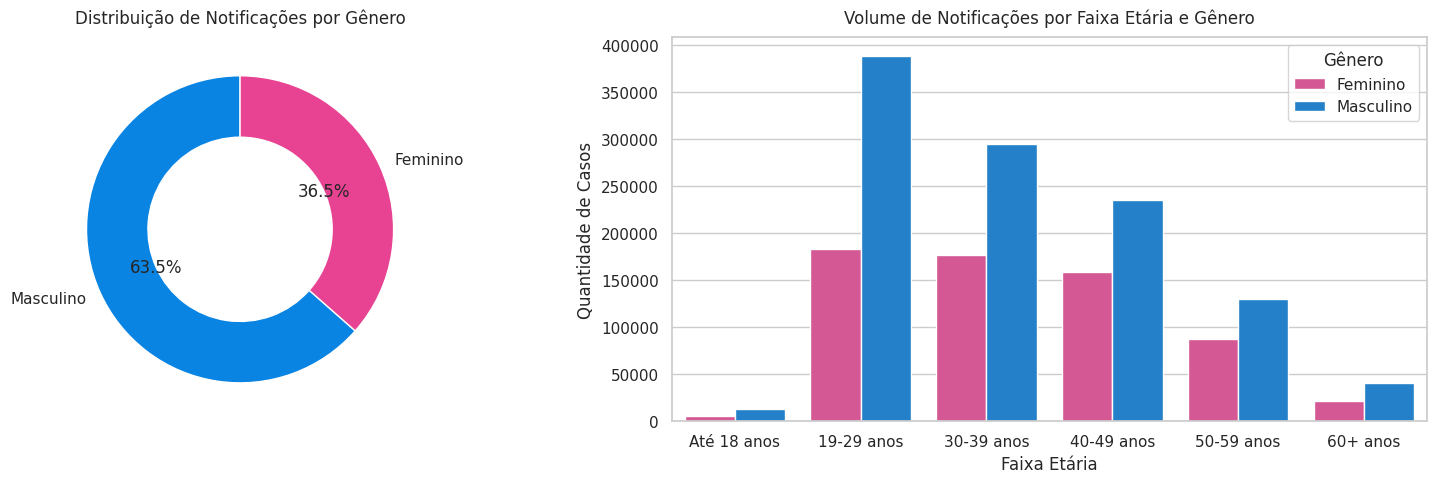

In [3]:
# Configurando o Seaborn
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)


# FAIXAS ETÁRIAS
# Criando faixas de 10 em 10 anos padrão IBGE/Mercado
bins = [0, 18, 29, 39, 49, 59, 100]
labels = [
    'Até 18 anos',
    '19-29 anos',
    '30-39 anos',
    '40-49 anos',
    '50-59 anos',
    '60+ anos',
]

df['faixa_etaria'] = pd.cut(
    df['idade'], bins=bins, labels=labels, right=True
)

### Centralizando o total de casos por gênero
qtd_genero = df['genero'].value_counts(dropna=False)
porcentagem_genero = df['genero'].value_counts(
    normalize=True, dropna=False
) * 100

df_genero = pd.DataFrame({'Total Casos': qtd_genero, 'Percentual (%)': porcentagem_genero})
print(df_genero.round(2))

# Gráficos para a exploraçao visual

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico 1: Pizza/Rosca de Distribuição por Genero
colors_gen = ['#0984E3', '#E84393']
axes[0].pie(
    df_genero['Total Casos'],
    labels=df_genero.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors_gen,
    wedgeprops=dict(width=0.4),
)
axes[0].set_title('Distribuição de Notificações por Gênero', fontsize=12, pad=10)

# Gráfico 2: Barras de Faixa Etária por Genero
sns.countplot(
    data=df,
    x='faixa_etaria',
    hue='genero',
    palette={'Feminino': '#E84393', 'Masculino': '#0984E3'},
    ax=axes[1],
)
axes[1].set_title(
    'Volume de Notificações por Faixa Etária e Gênero', fontsize=12, pad=10
)
axes[1].set_xlabel('Faixa Etária')
axes[1].set_ylabel('Quantidade de Casos')
axes[1].legend(title='Gênero')

plt.tight_layout()
plt.show()

### Homens são maioria em todas as faixas etárias

Com base na análise demográfica, observamos uma clara distinção na distribuição de notificações por gênero e faixa etária. Em relação ao gênero, **63.5% das notificações são de indivíduos do sexo Masculino**, enquanto **36.5% são do sexo Feminino**. Isso sugere uma maior incidência de afastamentos por burnout/transtornos mentais entre homens na base de dados analisada.

Ao investigar o volume de notificações por faixa etária, percebe-se que as categorias de **19-29 anos** e **30-39 anos** apresentam os maiores volumes de casos. Para ambas as faixas etárias, o **gênero Masculino consistentemente registra um número maior de notificações** em comparação com o gênero Feminino. As demais faixas etárias, como 40-49, 50-59 e 60+ anos, mostram uma diminuição progressiva no volume de notificações, mantendo a tendência de maior representatividade masculina.

## Geografia do Esgotamento: Mapeando a doença por UF de maior incidência.

Aqui podemos dividir em duas perguntas?

- Visão relativa: Qual é a representatividade proporcional de cada estado?

- Visão Absoluta: Quais Ufs concentram o maior número bruto de casos de afastamento?

- Vamos análisar aqui especificamente a coluna "uf_empregador" que trata-se da sede da empresa contratante

$$$$$$$$ Os 10 Estados com maior incidência de Burnout $$$$$$$$$$$
               UF  total_casos  porcentagem  porcentagem_acumulada
        São Paulo       604339    34.819235              34.819235
     Minas Gerais       165361     9.527341              44.346575
           Paraná       138825     7.998458              52.345033
Rio Grande do Sul       133749     7.706002              60.051036
   Santa Catarina       120976     6.970081              67.021117
   Rio de Janeiro       115562     6.658151              73.679268
            Goiás        47824     2.755399              76.434667
            Bahia        46807     2.696804              79.131471
   Espírito Santo        39022     2.248268              81.379739
       Pernambuco        35797     2.062459              83.442198


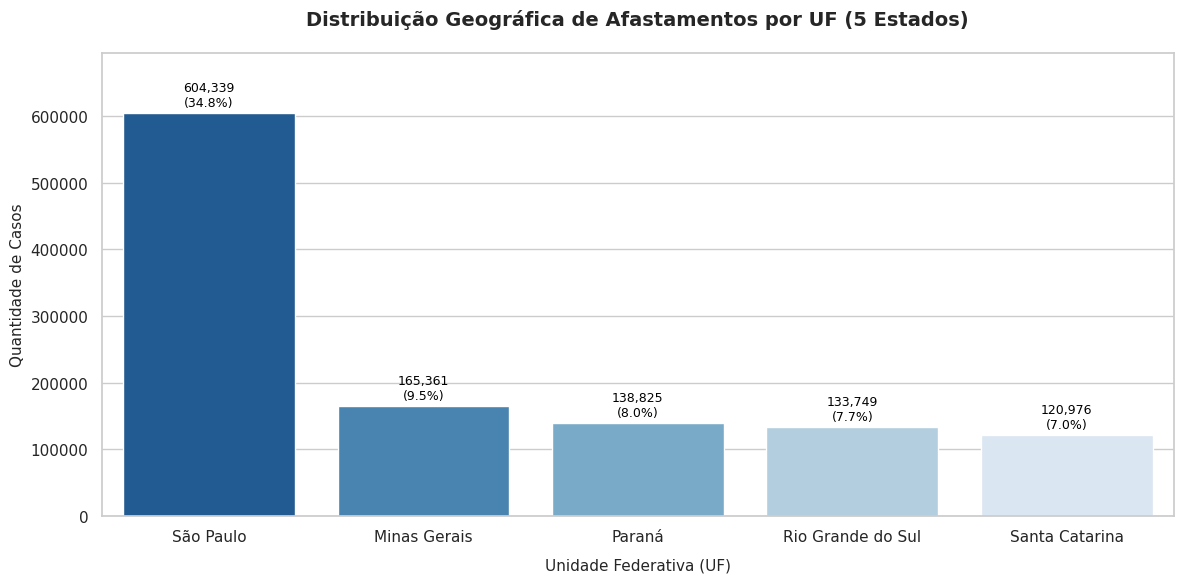

In [4]:
#### Agregando por UF

uf_analise = (
    df['uf_empregador']
    .value_counts()
    .reset_index()
    .rename(columns={'count': 'total_casos', 'uf_empregador': 'UF'})
)


# Calculo do percentual relativo

total_geral = uf_analise['total_casos'].sum()
uf_analise['porcentagem'] = (uf_analise['total_casos'] / total_geral) * 100
uf_analise['porcentagem_acumulada'] = uf_analise['porcentagem'].cumsum()

print('$$$$$$$$ Os 10 Estados com maior incidência de Burnout $$$$$$$$$$$')
print(uf_analise.head(10).to_string(index=False))

### Gráfico para as 15 UFS mais afetadas
plt.figure(figsize=(12, 6))

## Define os gradientes nas cores

palette = sns.color_palette('Blues_r', n_colors=len(uf_analise.head(5)))

ax = sns.barplot(
    data=uf_analise.head(5),
    x='UF',
    y='total_casos',
    palette=palette,
    hue='UF',
    legend=False,
)

# Adiciona os rótulos de contagem e porcentagem acima de cada barra
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        pct = (height / total_geral) * 100
        ax.annotate(
            f'{int(height):,}\n({pct:.1f}%)',
            (p.get_x() + p.get_width() / 2.0, height),
            ha='center',
            va='bottom',
            fontsize=9,
            color='black',
            xytext=(0, 3),
            textcoords='offset points',
        )

plt.title(
    'Distribuição Geográfica de Afastamentos por UF (5 Estados)',
    fontsize=14,
    pad=20,
    weight='bold',
)
plt.xlabel('Unidade Federativa (UF)', fontsize=11, labelpad=10)
plt.ylabel('Quantidade de Casos', fontsize=11)
plt.ylim(0, uf_analise['total_casos'].max() * 1.15)  # Espaço para as anotações
plt.tight_layout()

plt.show()


Agora veremos especificamente a coluna uf_acidente que trata-se de quando o empregado precisa viajar pra outro estado, ou a empresa sede contrata para trabalhar de outro estado e a doença ocorre no estado em que ela está trabalhando no momento.

--------------------- Os 10 Estados com maior incidência de afastamentos de saúde  quando olhamos para quando o empregado não é contratado
para trabalhar especificamente no estado da sede da empresa contratante ---------------------
UF  total_casos  porcentagem  porcentagem_acumulada
MA       616571    35.523986              35.523986
RO       170686     9.834143              45.358129
RR       140762     8.110059              53.468188
RS       133373     7.684339              61.152527
SC       120060     6.917305              68.069832
TO       116797     6.729306              74.799138
CE        62643     3.609202              78.408340
GO        47096     2.713455              81.121795
BA        46422     2.674622              83.796417
ES        38599     2.223897              86.020314


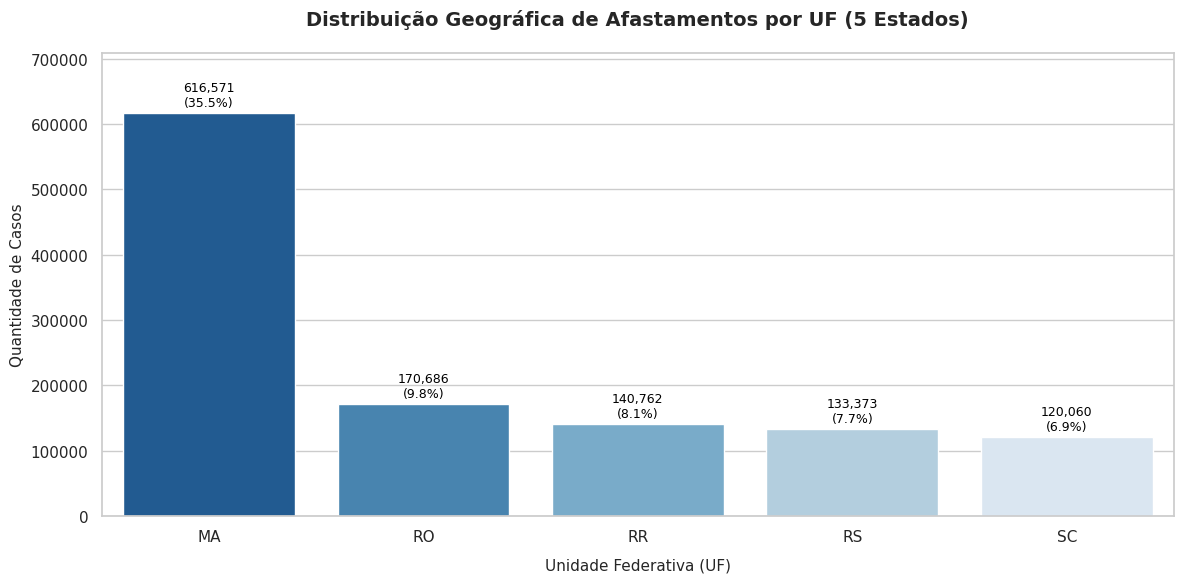

In [5]:
#### Agregando por UF

uf_analise = (
    df['uf_acidente']
    .value_counts()
    .reset_index()
    .rename(columns={'count': 'total_casos', 'uf_acidente': 'UF'})
)


# Calculo do percentual relativo

total_geral = uf_analise['total_casos'].sum()
uf_analise['porcentagem'] = (uf_analise['total_casos'] / total_geral) * 100
uf_analise['porcentagem_acumulada'] = uf_analise['porcentagem'].cumsum()

print('--------------------- Os 10 Estados com maior incidência de afastamentos de saúde  quando olhamos para quando o empregado não é contratado\n'
 'para trabalhar especificamente no estado da sede da empresa contratante ---------------------')
print(uf_analise.head(10).to_string(index=False))

### Gráfico para as 15 UFS mais afetadas
plt.figure(figsize=(12, 6))

## Define os gradientes nas cores

palette = sns.color_palette('Blues_r', n_colors=len(uf_analise.head(5)))

ax = sns.barplot(
    data=uf_analise.head(5),
    x='UF',
    y='total_casos',
    palette=palette,
    hue='UF',
    legend=False,
)

# Adiciona os rótulos de contagem e porcentagem acima de cada barra
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        pct = (height / total_geral) * 100
        ax.annotate(
            f'{int(height):,}\n({pct:.1f}%)',
            (p.get_x() + p.get_width() / 2.0, height),
            ha='center',
            va='bottom',
            fontsize=9,
            color='black',
            xytext=(0, 3),
            textcoords='offset points',
        )

plt.title(
    'Distribuição Geográfica de Afastamentos por UF (5 Estados)',
    fontsize=14,
    pad=20,
    weight='bold',
)
plt.xlabel('Unidade Federativa (UF)', fontsize=11, labelpad=10)
plt.ylabel('Quantidade de Casos', fontsize=11)
plt.ylim(0, uf_analise['total_casos'].max() * 1.15)  # Espaço para as anotações
plt.tight_layout()

plt.show()

Temos então uma quebra de crença aqui:
A Sede (UF Empregador): SP com 34.8% seguidos de MG(9.5%) e PR(8%) em segundo e terceiro lugares é a representação clássica do modelo corporativo brasileiro: grandes multinacionais, bancos, tech e grandes indústrias sediadas nos Sudeste e Sul.

A Operação e o Risco Real (UF Acidente): O Maranhão com 35.5% (616.571 casos) e Rondonia com 170.686 liderando disparado onde a CAT é registrada de fato desmonta totalmente a tese de "tem mais afastamentos em SP só porque tem mais gente".

Pode ser um alerta também a respeito da dinämica do trabalho desses estados mais afastados do centro, podendo indicar pode indicar indústrias extrativistas, grande agronegócio, obras de infraestrutura, logística intensiva ou operações terceirizadas/remotas com altíssima pressão física/mental e pouca estrutura de suporte.

vamos entender agora qual o munícipio de maior incidência no maranhão considerando que a incidencia é maior nesse estado:

Veremos qual tipo de operação no Maranhão e em Rondonia está gerando esse volume de afastamentos, cruzando o Município do Acidente com as nossas colunas limpas de CNAE (Setor Macro) e CBO (Grupo Macro).

In [6]:
## Filtrando apenas para os estados líderes de ocorrência
df_ma_ro = df[df['uf_acidente'].isin(['MA', 'RO'])]


## Agrupando por Estados, Municipios e Setores
municipios_risco = (
    df_ma_ro.groupby(['uf_acidente', 'municipio_empregador', 'cnae_setor_macro'])
    .size()
    .reset_index(name='total_casos')
    .sort_values(by='total_casos', ascending=False)
    )

print('10 Municipios com maior incidencia e seu setor predominante')
print(municipios_risco.head(10).to_string(index=False))

10 Municipios com maior incidencia e seu setor predominante
uf_acidente municipio_empregador                 cnae_setor_macro  total_casos
         MA            São Paulo     Outros_Servicos_E_Tecnologia        48348
         MA            São Paulo Teleatendimento_E_Servicos_Apoio        33306
         MA            São Paulo      Industria_Agro_E_Construcao        20879
         MA            São Paulo        Comercio_Varejo_E_Atacado        19710
         RO        Belo Horizont     Outros_Servicos_E_Tecnologia        11030
         MA            São Paulo         Saude_E_Servicos_Sociais         9873
         MA            São Paulo  Correios_Logistica_E_Transporte         8189
         RO        Belo Horizont Teleatendimento_E_Servicos_Apoio         6677
         MA            São Paulo                         Educacao         5952
         MA             Campinas     Outros_Servicos_E_Tecnologia         5729


### Esse cruzamento nos mostra:

**Sede Corporativa (Município Empregador):** Capitais São Paulo e Belo Horizonte concentram a gestão das empresas.

**Local Real do Afastamento (uf_acidente):** Maranhão e Rondonia.

**Setores Predominantes:** Tecnologia, Teleatendimento e Serviços dominam a lista

### E nos leva a levantar as seguintes hipóteses

- **Descentração Operacional e Terceirização / Call Centers / Polos Remotos:**
  - Grandes conglomerados bancários e empresas de tecnologia/serviços com sede em SP/MG **alocam pólos operacionais intensivos no Nordeste/Norte**, onde a carga de trabalho, metas de atendimento e pressão por produtividade são elevadíssimas.
  
#### Vamos visualizar em um gráfico esse achado:

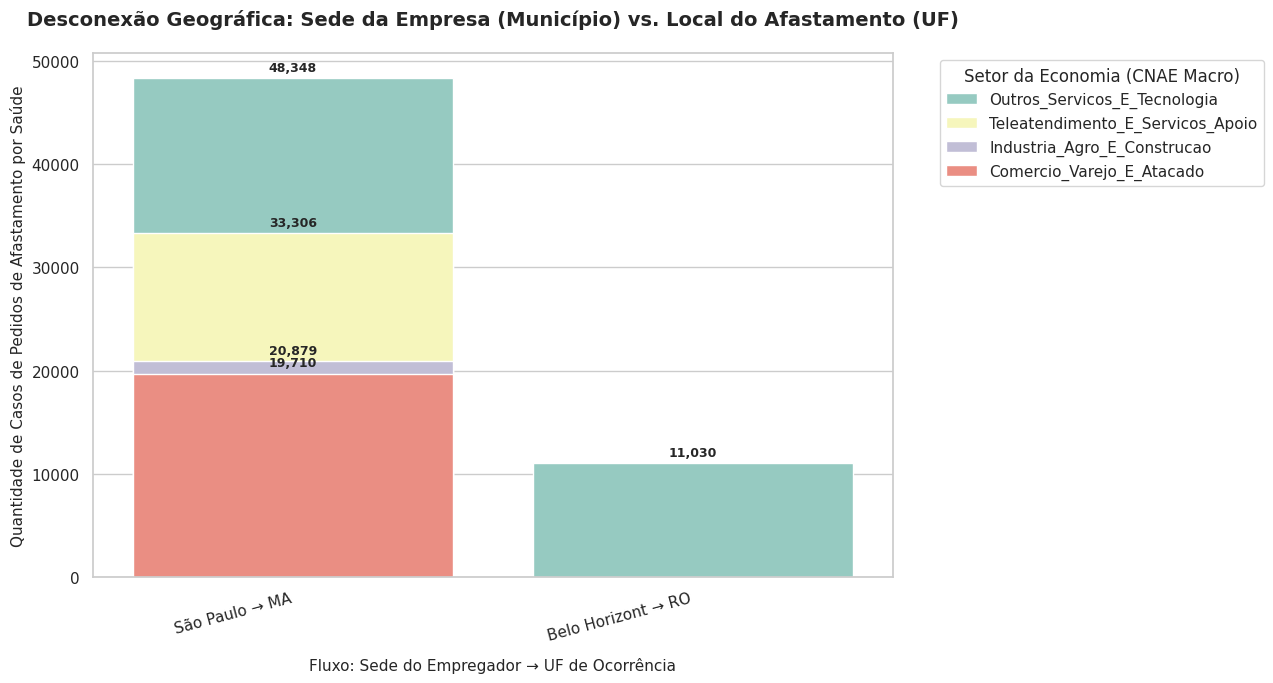

In [7]:
### configurando o estilo do gráfico
sns.set_theme(style='whitegrid')
plt.figure(figsize=(13, 7 ))

## Pegando os cruzamentos mais expressivos
cruzamentos = municipios_risco.head(5).copy()

#Criando um rótulo combinado
cruzamentos['relacao'] = (
    cruzamentos['municipio_empregador']
    + ' → ' + cruzamentos['uf_acidente']
)

# Gráfico de barras
ax = sns.barplot(
    data = cruzamentos,
    x='relacao',
    y='total_casos',
    hue='cnae_setor_macro',
    dodge=False,
    palette='Set3',
)

## Adiciona valores no topo das barras
for p in ax.patches:
  height = p.get_height()
  if height > 0:
    ax.annotate(
        f'{int(height):,}',
            (p.get_x() + p.get_width() / 2.0, height),
            ha='center',
            va='bottom',
            fontsize=9,
            weight='bold',
            xytext=(0, 3),
            textcoords='offset points',


    )

plt.title('Desconexão Geográfica: Sede da Empresa (Município) vs. Local do Afastamento (UF)',
fontsize=14,
pad=20,
weight='bold',
)
plt.xlabel('Fluxo: Sede do Empregador → UF de Ocorrência', fontsize=11, labelpad=10)
plt.ylabel('Quantidade de Casos de Pedidos de Afastamento por Saúde', fontsize=11)
plt.legend(title='Setor da Economia (CNAE Macro)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()

plt.show()

Vamos visualizar quem são os profissionais, cargos e funções estão sendo mais afetados e impactados nesses pólos descentralizados?

In [8]:
### Filtrando a base focando no fluxo cruzado do polo (sede: `sao paulo/BH --> Operação: Ma, RO)
coluna_cbo = ('cbo_grupo_macro' if 'cbo_grupo_macro' in df_ma_ro.columns else 'cbo_linha')

filtro_polo = ((df_ma_ro['uf_acidente'].isin(['MA', 'RO']))
& (
    df_ma_ro['municipio_empregador'].isin(
        ['São Paulo', 'Belo Horizonte', 'Campinas']
    )
))

df_polo = df_ma_ro[filtro_polo]


### Agrupando pela ocupação e setor macro

cargos_principais = (
    df_polo.groupby([coluna_cbo, 'cnae_setor_macro'])
    .size()
    .reset_index(name='total_casos')
    .sort_values(by='total_casos', ascending=False)
    .head(5)
)

print('####### 5 Cargos mais afetados nos pólos MA/RO (sede SP/BH) ########')
print(cargos_principais.to_string(index=False))


####### 5 Cargos mais afetados nos pólos MA/RO (sede SP/BH) ########
               cbo_grupo_macro                 cnae_setor_macro  total_casos
           Comercio_e_Servicos     Outros_Servicos_E_Tecnologia        27928
          Tecnicos_Nivel_Medio Teleatendimento_E_Servicos_Apoio        15544
Producao_Industrial_Artesanato      Industria_Agro_E_Construcao        15068
           Comercio_e_Servicos        Comercio_Varejo_E_Atacado         9218
Producao_Industrial_Artesanato     Outros_Servicos_E_Tecnologia         8997


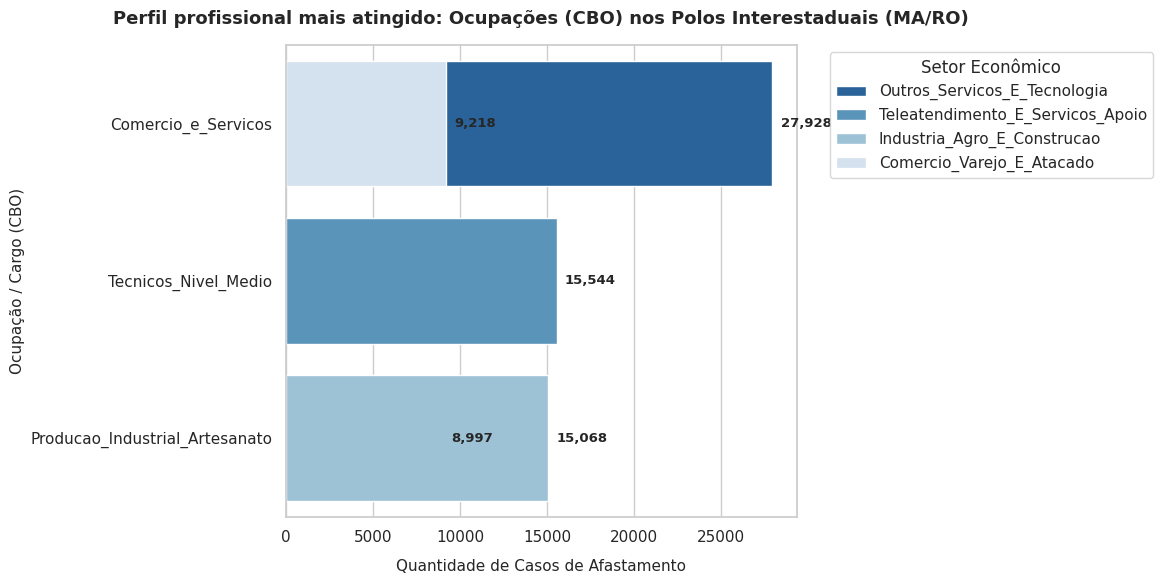

In [9]:
### Visualizando essa informação
plt.figure(figsize=(12, 6))
sns.set_theme(style='whitegrid')

ax = sns.barplot(
    data=cargos_principais,
    x='total_casos',
    y=coluna_cbo,
    hue='cnae_setor_macro',
    dodge=False,
    palette='Blues_r',
)

# Rótulos nas barras
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(
            f'{int(width):,}',
            (width, p.get_y() + p.get_height() / 2.0),
            xytext=(6, 0),
            textcoords='offset points',
            ha='left',
            va='center',
            fontsize=9.5,
            weight='bold',
        )

plt.title(
    'Perfil profissional mais atingido: Ocupações (CBO) nos Polos Interestaduais (MA/RO)',
    fontsize=13,
    weight='bold',
    pad=15,
)
plt.xlabel('Quantidade de Casos de Afastamento', fontsize=11, labelpad=10)
plt.ylabel('Ocupação / Cargo (CBO)', fontsize=11)
plt.legend(title='Setor Econômico', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()

### Olhando agora para as colunas de datas para analisar indicadores sobre:

- **Tempo de Latência de Notificação `data_emissao_cat` - `data_afastamento`**
:
Mede quantos dias a empresa levou para emitir a CAT após o funcionário ter sido afastado.

  - **O que indica:** Atrasos na formalização do acidente de trabalho.

- **Tempo de Subnotificação / Trabalho Doente `data_afastamento` - `data_acidente`**: Mede quantos dias o funcionário continuou trabalhando após a data registrada do evento/diagnóstico até o afastamento efetivo.

  - **O que indica:** Presenteísmo (trabalhar doente) ou resistência da gestão em liberar o profissional.


A representação das colunas de datas:

- data_acidente: É a data do diagnóstico médico ou do início do evento de esgotamento.

- data_afastamento: O primeiro dia em que o profissional deixou de trabalhar.

- data_emissao_cat: A data de formalização do documento no sistema.

In [10]:
## Primeiro um diagnostico pois sabemos que a unica coluna que possui nulos é a de data_afastamento
cols_data = ['data_acidente', 'data_afastamento', 'data_emissao_cat']

print('##### Dignóstico de nulos ####### ')
print(df_polo[cols_data].isna().sum())
print('\n% de Nulos:\n', (df_polo[cols_data].isna().mean() * 100).round(2))

### Criando uma cópia para calcular os intervalos
df_tempo = df_polo.copy()

### Primeiro intervalo: Dia do acidente (Data_acidente) até o afastamento efetivo
df_tempo['diasdiagnostico_ate_afastamento'] = (
    df_tempo['data_afastamento'] - df_tempo['data_acidente']
).dt.days

### Segundo intervalo: Dias de afastamento até a emissão da CAT
df_tempo['data_afastamento_ate_emissao'] = (
    df_tempo['data_emissao_cat'] - df_tempo['data_afastamento']
).dt.days


## Filtrando alguma inconsitencia caso exista data negativa na base

df_tempo.loc[df_tempo['diasdiagnostico_ate_afastamento'] < 0, 'diasdiagnostico_ate_afastamento'] = np.nan
df_tempo.loc[df_tempo['data_afastamento_ate_emissao'] < 0, 'data_afastamento_ate_emissao'] = np.nan


### Agrupando por CBO Macro (usando justamente a mediana)

resultado_t = (
    df_tempo.groupby('cbo_grupo_macro')
    .agg(
        casos_totais=('data_acidente', 'count'),
        mediana_dias_ate_afastar = ('diasdiagnostico_ate_afastamento', 'median'),
        mediana_dias_ate_emitir_cat = ('data_afastamento_ate_emissao', 'median'),
    )
    .reset_index()
    .sort_values(by='mediana_dias_ate_afastar', ascending = True)

)

print('#######\n Análise temporal pela categoria profissional ########')
print(resultado_t.to_string(index=False))

##### Dignóstico de nulos ####### 
data_acidente           0
data_afastamento    90746
data_emissao_cat        0
dtype: int64

% de Nulos:
 data_acidente        0.00
data_afastamento    53.79
data_emissao_cat     0.00
dtype: float64
#######
 Análise temporal pela categoria profissional ########
                           cbo_grupo_macro  casos_totais  mediana_dias_ate_afastar  mediana_dias_ate_emitir_cat
               Agropecuaria_Forestal_Pesca           803                       0.0                          2.0
                       Comercio_e_Servicos         53353                       0.0                          4.0
               Gestores_Diretores_Gerentes          4029                       0.0                          7.0
                    Manutencao_E_Reparacao          4662                       0.0                          4.0
                             Não Informado             7                       0.0                          6.0
           Operadores_Instalacoe

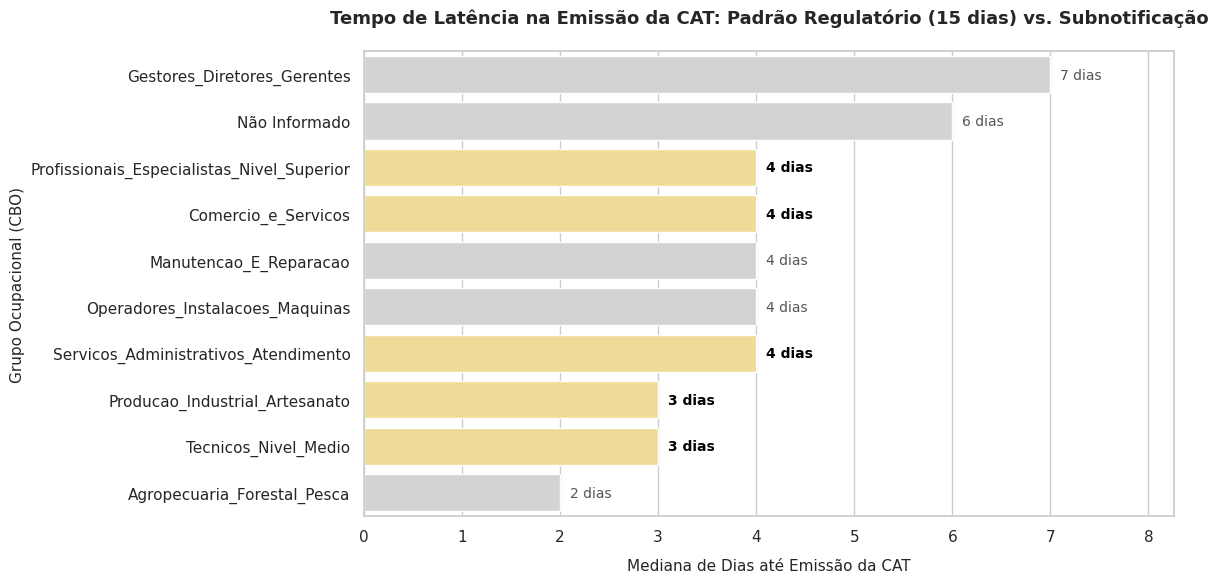

In [11]:
# Configuração visual
sns.set_theme(style='whitegrid')
fig, ax = plt.subplots(figsize=(12, 6))

# Ordenando a base
df_grafico = resultado_t.sort_values(
    by='mediana_dias_ate_emitir_cat', ascending=False
).copy()

# Definindo paleta com destaque visual para os 5 setores chave
setores_foco = [
    'Comercio_e_Servicos',
    'Producao_Industrial_Artesanato',
    'Tecnicos_Nivel_Medio',
    'Servicos_Administrativos_Atendimento',
    'Profissionais_Especialistas_Nivel_Superior'
]

cores = [
    '#fce38a' if cbo in setores_foco else '#d3d3d3'
    for cbo in df_grafico['cbo_grupo_macro']
]

# Plotando do gráfico de barras
bars = sns.barplot(
    data=df_grafico,
    x='mediana_dias_ate_emitir_cat',
    y='cbo_grupo_macro',
    palette=cores,
    hue='cbo_grupo_macro',
    legend=False,
)

# Rótulos customizados em cada barra
for p, cbo in zip(ax.patches, df_grafico['cbo_grupo_macro']):
    width = p.get_width()
    if not np.isnan(width) and width > 0:
        # Se for um dos 3 principais, destaca o texto em negrito
        peso_fonte = 'bold' if cbo in setores_foco else 'normal'
        cor_texto = '#000000' if cbo in setores_foco else '#555555'

        ax.annotate(
            f'{width:.0f} dias',
            (width, p.get_y() + p.get_height() / 2.0),
            xytext=(7, 0),
            textcoords='offset points',
            ha='left',
            va='center',
            fontsize=10,
            weight=peso_fonte,
            color=cor_texto,
        )

# Formatando Título e Eixos
plt.title(
    'Tempo de Latência na Emissão da CAT: Padrão Regulatório (15 dias) vs. Subnotificação',
    fontsize=13,
    weight='bold',
    pad=20,
)
plt.xlabel('Mediana de Dias até Emissão da CAT', fontsize=11, labelpad=10)
plt.ylabel('Grupo Ocupacional (CBO)', fontsize=11)
plt.xlim(0, df_grafico['mediana_dias_ate_emitir_cat'].max() * 1.18)

plt.tight_layout()
plt.show()

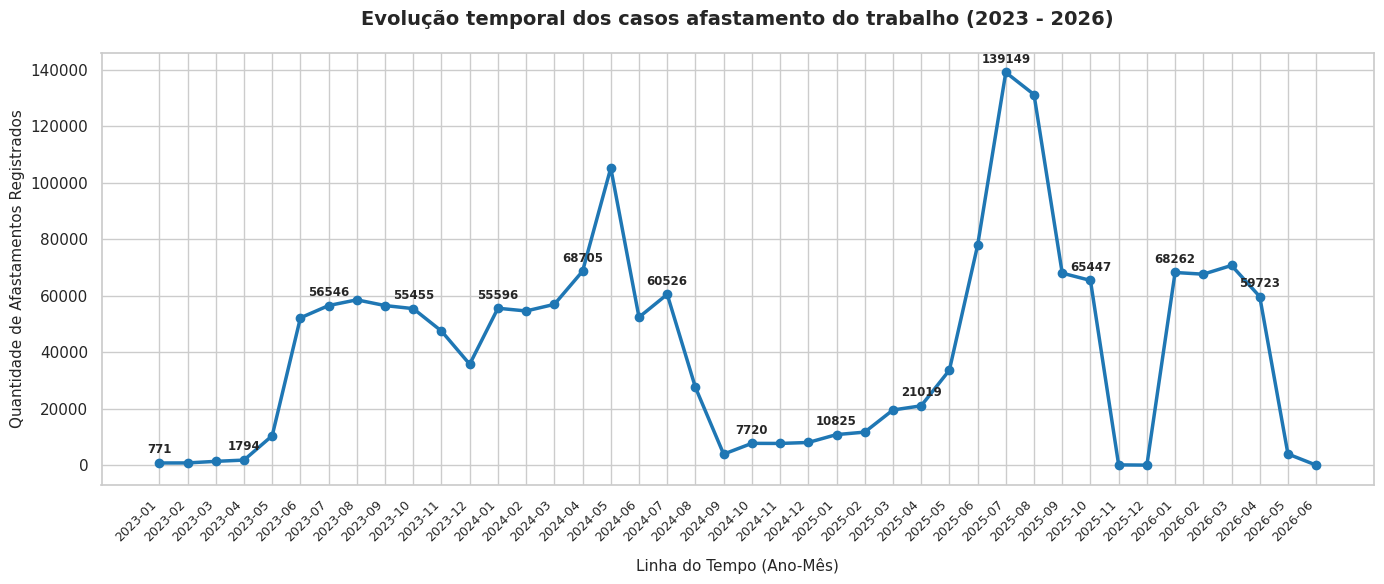

###### TOTAL DE CASOS POR ANO (2023 - 2026) #####
 ano  total_casos  crescimento_porcentagem
2023       377685                      NaN
2024       509021                34.773952
2025       578588                13.666823
2026       270353               -53.273659


In [12]:
#### Convertendo e extraindo o ano e o mês utilizando a data_acidente
col_data = 'data_acidente'
df[col_data] = pd.to_datetime(df[col_data], errors='coerce')


### filtrando pra o intervalo de interesse
df_temporal = df[(df[col_data].dt.year >= 2023) &
                            (df[col_data].dt.year <= 2026)].copy()

## Coluna de ano_mes para a linha do tempo
df_temporal['ano_mes'] = df_temporal[col_data].dt.to_period('M')

### Agrupando as contagens por mês
evolucao_mensal = (
    df_temporal.groupby('ano_mes')
    .size()
    .reset_index(name='total_casos')
)
evolucao_mensal['ano_mes_str'] = evolucao_mensal['ano_mes'].astype(str)


## Gerando o gráfico
plt.figure(figsize=(14, 6))
sns.set_theme(style='whitegrid')

# Linha principal
plt.plot(
    evolucao_mensal['ano_mes_str'],
    evolucao_mensal['total_casos'],
    marker='o',
    color='#1f77b4',
    linewidth=2.5,
    markersize=6,
    label='Casos Mensais',
)

# Adicionar rótulos nos picos/pontos principais
for i, row in evolucao_mensal.iterrows():
    # Destaca pontos de pico ou início/fim de anos
    if i % 3 == 0 or row['total_casos'] == evolucao_mensal['total_casos'].max():
        plt.annotate(
            f"{row['total_casos']}",
            (row['ano_mes_str'], row['total_casos']),
            xytext=(0, 7),
            textcoords='offset points',
            ha='center',
            fontsize=8.5,
            weight='bold',
        )

plt.title(
    'Evolução temporal dos casos afastamento do trabalho (2023 - 2026)',
    fontsize=14,
    weight='bold',
    pad=20,
)
plt.xlabel('Linha do Tempo (Ano-Mês)', fontsize=11, labelpad=10)
plt.ylabel('Quantidade de Afastamentos Registrados', fontsize=11)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()

plt.show()

# 4. Tabela Resumo Consolidada por Ano
resumo_anual = (
    df_temporal[col_data]
    .dt.year.value_counts()
    .sort_index()
    .reset_index(name='total_casos')
    .rename(columns={col_data: 'ano'})
)
resumo_anual['crescimento_porcentagem'] = (
    resumo_anual['total_casos'].pct_change() * 100
)

print('###### TOTAL DE CASOS POR ANO (2023 - 2026) #####')
print(resumo_anual.to_string(index=False))

##### Distribuiçao percentual % da faixa etária por cargo
faixa_etaria                    Até 18 anos  19-29 anos  30-39 anos  40-49 anos  50-59 anos
cbo_grupo_macro                                                                            
Comercio_e_Servicos                    1.26       31.05       24.66       22.83       15.53
Producao_Industrial_Artesanato         1.01       32.92       26.85       22.74       12.65
Tecnicos_Nivel_Medio                   0.20       30.20       30.37       26.04       10.89


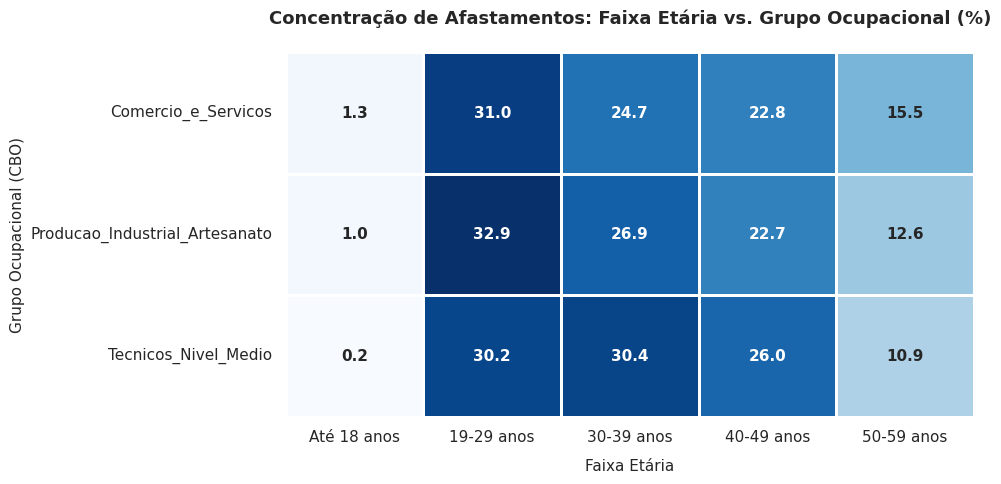

In [13]:
# Garantindo a ordem das faixas etárias
ordem_faixa = [
    'Até 18 anos',
    '19-29 anos',
    '30-39 anos',
    '40-49 anos',
    '50-59 anos',
    '60-69 anos',
    '70+ anos',
]

## Filtro focado nos principais grupos
cargos_foco = [
    'Comercio_e_Servicos',
    'Producao_Industrial_Artesanato',
    'Tecnicos_Nivel_Medio',
]

df_cruzamento = df[
    df['cbo_grupo_macro'].isin(cargos_foco)
].copy()


#### Tabela de cruzamento proporcional em %
tabela_cruzada = (
    pd.crosstab(
        df_cruzamento['cbo_grupo_macro'],
        df_cruzamento['faixa_etaria'],
        normalize='index',
    ) * 100
)

#Reordenar colunas conforme a ordem lógica da idade
cols_existente = [col for col in ordem_faixa if col in tabela_cruzada.columns]
tabela_cruzada = tabela_cruzada[cols_existente]

print('##### Distribuiçao percentual % da faixa etária por cargo')
print(tabela_cruzada.round(2).to_string())


### Montando o gráfico: usaremos o heatmap (Mapa de calor)

plt.figure(figsize=(10, 5))
sns.set_theme(style='white')

ax = sns.heatmap(
    tabela_cruzada,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    cbar=False,
    linewidths=1,
    linecolor='white',
    annot_kws={'weight': 'bold', 'size': 11},
)

plt.title(
    'Concentração de Afastamentos: Faixa Etária vs. Grupo Ocupacional (%)',
    fontsize=13,
    weight='bold',
    pad=20,
)
plt.xlabel('Faixa Etária', fontsize=11, labelpad=10)
plt.ylabel('Grupo Ocupacional (CBO)', fontsize=11)
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()